# DEEP BATCH ACTIVE LEARNING BY DIVERSE, UNCERTAIN GRADIENT LOWER BOUNDS

Jordan T. Ash, Chicheng Zhang, Akshay Krishnamurthy, John Langford, and Alekh Agarwal.

This notebook gives a smoke-sized, single-method tutorial for BADGE.

**What this notebook gives you:** a runnable package walkthrough, a small supervised setup, and one active-learning run.

**Two ways to use this:** run the bundled example, or replace the loader inputs with your own data.

**What this notebook does NOT do:** it is not a benchmark and does not implement baselines. It uses system-default `pool_size` and `num_rounds` rather than the paper's full training set and 349 rounds; it uses inferred `max_epochs` and `hidden_dim` for the smoke training budget/model width; and it runs one seed rather than repeated experiments. The bundled flattened MLP is a demo architecture, not the paper's full image-architecture benchmark.

## Contents

- [0. Install dependencies (first run only)](#sec-0-install-dependencies-first-run-only)
- [1. Setup](#sec-1-setup)
- [2. Parameters](#sec-2-parameters)
  - [Optional: scale up to paper-faithful values](#sec-optional-scale-up-to-paper-faithful-values)
- [3. The setup pieces](#sec-3-the-setup-pieces)
- [3.1 Data](#sec-31-data)
- [3.2 Model](#sec-32-model)
- [3.3 Training](#sec-33-training)
- [3.4 Bootstrap](#sec-34-bootstrap)
- [4. The method ⭐](#sec-4-the-method)
  - [4.1 Intuition](#sec-41-intuition)
  - [4.2 Hallucinated gradient embeddings ⭐](#sec-42-hallucinated-gradient-embeddings)
  - [4.3 Sequential k-MEANS++ selection ⭐](#sec-43-sequential-k-means-selection)
  - [4.4 Putting it together](#sec-44-putting-it-together)
- [5. Running active learning end-to-end](#sec-5-running-active-learning-end-to-end)
  - [5.1 Acquisition loop](#sec-51-acquisition-loop)
  - [5.2 Learning curve](#sec-52-learning-curve)
- [6. Use your own data](#sec-6-use-your-own-data)

<a id="sec-0-install-dependencies-first-run-only"></a>

## 0. Install dependencies (first run only)

Install the package requirements into the active notebook kernel.

In [1]:
%pip install -r requirements.txt


[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: pip3 install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


<a id="sec-1-setup"></a>

## 1. Setup

In [2]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import torch
from method import (select_batch, compute_gradient_embeddings,
                    kmeans_plus_plus_seeding, BADGEClassifier,
                    build_model, train_from_scratch, load_data)
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

<a id="sec-2-parameters"></a>

## 2. Parameters

The table distinguishes values taken from the paper from values inferred or selected for this demo.

| Parameter | Variable from paper | Value from paper | Paper value | System value | Where in paper | Used? | Notes |
|---|:-:|:-:|---|---|---|:-:|---|
| `batch_size` | ✅ | ✅ | 100 | — | Algorithm 1 / Section 4 | ✅ | Paper uses batch_size=100 per data_setup. |
| `num_rounds` | ✅ | ✅ | 349 | 5 | — | ✅ | Paper runs 349 rounds (~34,900 labels at batch_size=100). At smoke scale we... |
| `initial_labeled` | ✅ | ✅ | 100 | — | Algorithm 1 / Section 4 | ✅ | Paper bootstraps with 100 uniformly-random labeled examples. |
| `pool_size` | ✅ | ✅ | 'full training set' | 12000 | — | ✅ | Paper uses the full training set (typically 60k–73k samples) as the... |
| `learning_rate` | ✅ | ✅ | 0.001 | — | Section 4 | ✅ | Adam optimizer at 0.001. Spec training.learning_rate: '0.001 for image data... |
| `max_epochs` | ❌ | ❌ | — | 200 | — | ✅ | AUTO-RAISED (A001): max_epochs raised from 8 to 200. The training-budget... |
| `train_until_accuracy` | ✅ | ✅ | 0.99 | — | Section 4 EXPERIMENTS | ✅ | Paper-stated training threshold: 'models using cross-entropy loss and the... |
| `hidden_dim` | ❌ | ❌ | — | 256 | — | ✅ | Paper states no data-type-keyed MLP width. We use hidden_dim=256 as the... |

In [3]:
params = {
    "batch_size": {
        "value": 100,
        "source": 'paper',
        "paper_section": 'Algorithm 1 / Section 4',
        "note": 'Paper uses batch_size=100 per data_setup.',
    },
    "num_rounds": {
        "value": 5,
        "source": 'system_default',
        "paper_value": 349,
        "reasoning": (
            "Paper runs 349 rounds (~34,900 labels at batch_size=100). At smoke "
            "scale we run 5 rounds at runtime batch_size=100 (~500 labels) — enough "
            "to see a learning curve emerge while keeping the acquisition loop "
            "(which re-trains and re-scores the pool every round) cheap to run on a "
            "laptop CPU at smoke scale."
        ),
        "unused_by_method": True,
    },
    "initial_labeled": {
        "value": 100,
        "source": 'paper',
        "paper_section": 'Algorithm 1 / Section 4',
        "note": 'Paper bootstraps with 100 uniformly-random labeled examples.',
        "unused_by_method": True,
    },
    "pool_size": {
        "value": 12000,
        "source": 'system_default',
        "paper_value": 'full training set',
        "reasoning": (
            "Paper uses the full training set (typically 60k–73k samples) as the "
            "unlabeled pool. We subsample to 12,000 to keep each round's "
            "acquisition-scoring pass over the whole pool cheap (the pool is "
            "re-scored every round, so this is the dominant cost of the acquisition "
            "loop). Raised further to 12,000 to satisfy the taxonomy "
            "smoke_economics max_budget_to_pool_ratio floor (0.05); a smaller pool "
            "would over-consume the unlabeled set and weaken diversity-sensitive "
            "acquisition checks. Note: this is a smoke-scale default, not a runtime "
            "estimate — the smoke gate is what actually verifies the notebook fits "
            "its per-cell time budget. Pool ratio (total_budget / pool_size) ≈ "
            "0.05. This is at or below the taxonomy smoke_economics "
            "`max_budget_to_pool_ratio` of 0.05 — diversity baselines are still "
            "meaningfully tested at this scale."
        ),
    },
    "learning_rate": {
        "value": 0.001,
        "source": 'paper',
        "paper_section": 'Section 4',
        "note": (
            "Adam optimizer at 0.001. Spec training.learning_rate: '0.001 for image "
            "data and 0.0001 for non-image data'. Selected image-data value."
        ),
    },
    "max_epochs": {
        "value": 200,
        "source": 'system_inferred',
        "reasoning": (
            "AUTO-RAISED (A001): max_epochs raised from 8 to 200. The "
            "training-budget sufficiency check found the derived budget could not "
            "fit a separable toy set sized to the round-one labeled set (train acc "
            "0.3333 vs chance+margin 0.5833); 200 epochs fit it with batch and "
            "learning rate unchanged. See assumptions.md entry A001. Previous "
            "reasoning: Paper trains to an explicit training-accuracy threshold "
            "with no stated epoch cap. At smoke scale the labeled sets are tiny (≤ "
            "~500 examples) and `train_until_accuracy` usually stops well before "
            "the cap; 8 is a low safety bound that keeps per-round training fast at "
            "smoke scale. Increase it for full-scale training."
        ),
    },
    "train_until_accuracy": {
        "value": 0.99,
        "source": 'paper',
        "paper_section": 'Section 4 EXPERIMENTS',
        "note": (
            "Paper-stated training threshold: 'models using cross-entropy loss and "
            "the Adam variant of SGD until training accuracy exceeds 99%'."
        ),
    },
    "hidden_dim": {
        "value": 256,
        "source": 'system_inferred',
        "reasoning": (
            "Paper states no data-type-keyed MLP width. We use hidden_dim=256 as "
            "the taxonomy-typical AL convention."
        ),
    },
}


def unpack(p: dict) -> dict:
    """Strip provenance and return a flat name -> value dict."""
    return {k: v["value"] for k, v in p.items() if v.get("used_in_notebook", True)}


cfg = unpack(params)

<a id="sec-optional-scale-up-to-paper-faithful-values"></a>

### Optional: scale up to paper-faithful values

The paper-faithful run also requires the full dataset, round budget, and paper benchmark architectures.

In [4]:
# cfg.update({
#     "pool_size": "full training set",
#     "num_rounds": 349,
#     "max_epochs": "train until accuracy exceeds 0.99",
# })
# True paper-faithfulness for image data also requires swapping the bundled flattened MLP for the paper's MLP, ResNet-18, or VGG architecture.

<a id="sec-3-the-setup-pieces"></a>

## 3. The setup pieces

<a id="sec-31-data"></a>

## 3.1 Data

In [5]:
x_pool, y_pool, x_test, y_test = load_data(pool_size=cfg["pool_size"], n_test=1000, seed=SEED)
print("pool", tuple(x_pool.shape), "test", tuple(x_test.shape), "classes", int(torch.unique(y_pool).numel()))

  0%|          | 0.00/9.91M [00:00<?, ?B/s]

  1%|          | 98.3k/9.91M [00:00<00:16, 611kB/s]

  2%|▏         | 197k/9.91M [00:00<00:13, 717kB/s] 

  4%|▍         | 426k/9.91M [00:00<00:07, 1.29MB/s]

  8%|▊         | 786k/9.91M [00:00<00:04, 1.98MB/s]

...

 48%|████▊     | 786k/1.65M [00:00<00:00, 1.85MB/s]

100%|██████████| 1.65M/1.65M [00:00<00:00, 2.64MB/s]

  0%|          | 0.00/4.54k [00:00<?, ?B/s]

100%|██████████| 4.54k/4.54k [00:00<00:00, 2.60MB/s]

pool (12000, 784) test (1000, 784) classes 10


<a id="sec-32-model"></a>

## 3.2 Model

In [6]:
model = build_model(input_dim=x_pool.shape[1], n_classes=int(torch.unique(y_pool).numel()), hidden_dim=cfg["hidden_dim"])
print(model)

BADGEClassifier(
  (encoder): Sequential(
    (0): Linear(in_features=784, out_features=256, bias=True)
    (1): ReLU()
  )
  (classifier): Linear(in_features=256, out_features=10, bias=True)
)


<a id="sec-33-training"></a>

## 3.3 Training

In [7]:
# BADGE follows the paper's cross-entropy + Adam, retrain-from-scratch protocol (**Section 4**).
print("Training is performed after bootstrap and after every acquisition round.")

Training is performed after bootstrap and after every acquisition round.


<a id="sec-34-bootstrap"></a>

## 3.4 Bootstrap

In [8]:
rng = np.random.default_rng(SEED)
bootstrap_labeled_idx = rng.choice(len(x_pool), size=min(100, len(x_pool)), replace=False)
labeled_idx = set(int(i) for i in bootstrap_labeled_idx)
model = build_model(input_dim=x_pool.shape[1], n_classes=int(torch.unique(y_pool).numel()), hidden_dim=cfg["hidden_dim"])
model = train_from_scratch(model, x_pool[bootstrap_labeled_idx], y_pool[bootstrap_labeled_idx],
                           learning_rate=cfg["learning_rate"], max_epochs=cfg["max_epochs"],
                           train_until_accuracy=cfg["train_until_accuracy"], seed=SEED)
model.eval()
with torch.no_grad():
    bootstrap_accuracy = (model(x_test).argmax(1) == y_test).float().mean().item()
print(f"bootstrap accuracy: {bootstrap_accuracy:.3f}")

bootstrap accuracy: 0.744


<a id="sec-4-the-method"></a>

## 4. The method ⭐

<a id="sec-41-intuition"></a>

### 4.1 Intuition

BADGE uses the model's predicted label to form a usable gradient before querying the true label. The resulting last-layer gradient embedding is large for uncertain predictions and retains the penultimate representation, so geometry can express both influence and diversity (**Section 3, Equation (1)**; `concept-hallucinated-label`, `eq-gradient-embedding`). Sequential k-MEANS++ then favors candidates far from already selected embeddings (**Appendix A, Algorithm 2**). These are the two core methodology elements; this notebook does not replace either with confidence or top-K scoring.

<a id="sec-42-hallucinated-gradient-embeddings"></a>

### 4.2 Hallucinated gradient embeddings ⭐

For a predicted class, BADGE forms each output-class block as `(p_i - I[hat y=i]) z(x; V)` (**Equation (1), Section 3**; `eq-gradient-embedding`).

<!-- derived-block: begin {"kind": "implementation_note", "spec": {"element_ids": ["eq-gradient-embedding", "eq-softmax-cross-entropy"], "file": "method/method.py", "qualname": "compute_gradient_embeddings"}} -->
**How this is implemented:** [`compute_gradient_embeddings`](method/method.py) (`method/method.py:18`) implements [Hallucinated final-layer gradient embedding](METHOD.md#eq-gradient-embedding), [Softmax cross-entropy in last-layer parameterization](METHOD.md#eq-softmax-cross-entropy).

<details>
<summary>Source of <code>compute_gradient_embeddings</code> (29 lines)</summary>

**Source: `compute_gradient_embeddings` — method/method.py:18**

```python
def compute_gradient_embeddings(model: Any, x_unlabeled: torch.Tensor) -> torch.Tensor:
    """Compute hallucinated-label last-layer gradients (Eq. 1, Section 3).

    Args:
        model: Trained classifier exposing ``forward_with_embedding``.
        x_unlabeled: Pool tensor with one row per candidate.
    Returns:
        Tensor whose rows are flattened classifier-weight gradients, with
        shape ``(pool_size, class_count * embedding_width)``.
    """
    # paper-element: eq-gradient-embedding
    # paper-element: eq-softmax-cross-entropy
    # essential: Final output layer with differentiable cross-entropy scores
    # essential: Penultimate-layer representation
    was_training = model.training
    model.eval()
    try:
        with torch.no_grad():
            logits, embedding = model.forward_with_embedding(x_unlabeled)
            probabilities = F.softmax(logits, dim=1)
            predicted = probabilities.argmax(dim=1)
            one_hot = torch.zeros_like(probabilities)
            one_hot.scatter_(1, predicted[:, None], 1.0)
            classifier_gradient = probabilities - one_hot
            return (classifier_gradient[:, :, None] * embedding[:, None, :]).reshape(
                embedding.shape[0], -1
            )
    finally:
        model.train(was_training)
```

</details>
<!-- derived-block: end -->

In [9]:
model.eval()
with torch.no_grad():
    demo_embeddings = compute_gradient_embeddings(model, x_pool[:100])
print("gradient embedding shape:", tuple(demo_embeddings.shape))
print("embedding norms:", demo_embeddings.detach().norm(dim=1)[:5].numpy())

gradient embedding shape: (100, 2560)
embedding norms: [4.313692  4.9004507 5.2276177 1.3266829 8.039325 ]


<a id="sec-43-sequential-k-means-selection"></a>

### 4.3 Sequential k-MEANS++ selection ⭐

The first center is uniform; each later center is sampled in proportion to squared distance from its nearest selected center (**Appendix A, Algorithm 2**; `alg-kmeans-plus-plus`).

<!-- derived-block: begin {"kind": "implementation_note", "spec": {"element_ids": ["alg-kmeans-plus-plus"], "file": "method/method.py", "qualname": "kmeans_plus_plus_seeding"}} -->
**How this is implemented:** [`kmeans_plus_plus_seeding`](method/method.py) (`method/method.py:49`) implements [k-MEANS++ seeding sampler](METHOD.md#alg-kmeans-plus-plus).

<details>
<summary>Source of <code>kmeans_plus_plus_seeding</code> (38 lines)</summary>

**Source: `kmeans_plus_plus_seeding` — method/method.py:49**

```python
def kmeans_plus_plus_seeding(
    embeddings: np.ndarray, batch_size: int, *, rng: np.random.Generator
) -> np.ndarray:
    """Select diverse centers with sequential k-MEANS++ seeding (Algorithm 1).

    Distances are maintained incrementally as the nearest-center squared
    distance, which is algebraically equivalent to the paper's ``D(x)^2``.
    """
    # paper-element: alg-kmeans-plus-plus
    if embeddings.ndim != 2:
        raise ValueError("embeddings must be a two-dimensional array")
    n_points = embeddings.shape[0]
    if n_points == 0:
        return np.empty(0, dtype=np.int64)
    count = min(max(int(batch_size), 0), n_points)
    if count == 0:
        return np.empty(0, dtype=np.int64)

    selected = np.empty(count, dtype=np.int64)
    selected[0] = int(rng.integers(n_points))
    min_squared_distance = np.sum(
        (embeddings - embeddings[selected[0]]) ** 2, axis=1
    )
    for position in range(1, count):
        total = float(min_squared_distance.sum())
        if not np.isfinite(total) or total <= 0.0:
            # paper-fidelity: duplicate/equidistant smoke pools have no
            # meaningful k-MEANS++ distribution; choose an unselected point.
            available = np.setdiff1d(np.arange(n_points), selected[:position])
            selected[position] = int(rng.choice(available))
        else:
            probabilities = min_squared_distance / total
            selected[position] = int(rng.choice(n_points, p=probabilities))
        new_squared_distance = np.sum(
            (embeddings - embeddings[selected[position]]) ** 2, axis=1
        )
        min_squared_distance = np.minimum(min_squared_distance, new_squared_distance)
    return selected
```

</details>
<!-- derived-block: end -->

In [10]:
demo_centers = kmeans_plus_plus_seeding(demo_embeddings.detach().cpu().numpy(), 10,
                                        rng=np.random.default_rng(SEED))
print("selected center positions:", demo_centers)

selected center positions: [ 8 46 86 75  9 94 77 79 11 48]


<a id="sec-44-putting-it-together"></a>

### 4.4 Putting it together

`select_batch` composes the predicted-label gradient construction and sequential k-MEANS++ sampler into the paper's acquisition rule (**Algorithm 1, Section 3**; `alg-badge`).

<a id="sec-5-running-active-learning-end-to-end"></a>

## 5. Running active learning end-to-end

<a id="sec-51-acquisition-loop"></a>

### 5.1 Acquisition loop

<!-- derived-block: begin {"kind": "implementation_note", "spec": {"element_ids": ["alg-badge"], "file": "method/method.py", "qualname": "select_batch"}} -->
**How this is implemented:** [`select_batch`](method/method.py) (`method/method.py:89`) implements [BADGE batch active learning](METHOD.md#alg-badge).

<details>
<summary>Source of <code>select_batch</code> (13 lines)</summary>

**Source: `select_batch` — method/method.py:89**

```python
def select_batch(model: Any, x_unlabeled: torch.Tensor, batch_size: int, *, seed: int) -> torch.Tensor:
    """Return pool indices selected by BADGE (Algorithm 1, Section 3).

    The requested count is clamped only to the available pool, an
    accommodation for smoke-sized pools that is a no-op at paper scale.
    """
    # paper-element: alg-badge
    rng = np.random.default_rng(seed)
    embeddings = compute_gradient_embeddings(model, x_unlabeled)
    selected = kmeans_plus_plus_seeding(
        embeddings.detach().cpu().numpy(), batch_size, rng=rng
    )
    return torch.as_tensor(selected, dtype=torch.int64, device=x_unlabeled.device)
```

</details>
<!-- derived-block: end -->

In [11]:
labels_history = []
accuracy_history = []
bootstrap_source = np.asarray(bootstrap_labeled_idx, dtype=np.int64)
labeled_idx = set(int(i) for i in bootstrap_source)
model = build_model(input_dim=x_pool.shape[1], n_classes=int(torch.unique(y_pool).numel()), hidden_dim=cfg["hidden_dim"])
model = train_from_scratch(model, x_pool[bootstrap_source], y_pool[bootstrap_source],
                           learning_rate=cfg["learning_rate"], max_epochs=cfg["max_epochs"],
                           train_until_accuracy=cfg["train_until_accuracy"], seed=SEED)
model.eval()
with torch.no_grad():
    bootstrap_accuracy = (model(x_test).argmax(1) == y_test).float().mean().item()
labels_history.append(len(labeled_idx)); accuracy_history.append(bootstrap_accuracy)
print(f"bootstrap: labels={len(labeled_idx)} test_accuracy={bootstrap_accuracy:.3f}")
for round_id in range(int(cfg["num_rounds"])):
    unlabeled_idx = np.asarray(sorted(set(range(len(x_pool))) - labeled_idx), dtype=np.int64)
    if len(unlabeled_idx) == 0:
        break
    chosen_positions = select_batch(model, x_pool[unlabeled_idx], int(cfg["batch_size"]), seed=SEED + round_id)
    chosen = unlabeled_idx[chosen_positions.detach().cpu().numpy()]
    labeled_idx.update(int(i) for i in chosen)
    model = build_model(input_dim=x_pool.shape[1], n_classes=int(torch.unique(y_pool).numel()), hidden_dim=cfg["hidden_dim"])
    model = train_from_scratch(model, x_pool[sorted(labeled_idx)], y_pool[sorted(labeled_idx)],
                               learning_rate=cfg["learning_rate"], max_epochs=cfg["max_epochs"],
                               train_until_accuracy=cfg["train_until_accuracy"], seed=SEED + round_id + 1)
    model.eval()
    with torch.no_grad():
        post_accuracy = (model(x_test).argmax(1) == y_test).float().mean().item()
    labels_history.append(len(labeled_idx)); accuracy_history.append(post_accuracy)
    print(f"round {round_id + 1}: labels={len(labeled_idx)} test_accuracy={post_accuracy:.3f}")

bootstrap: labels=100 test_accuracy=0.731


round 1: labels=200 test_accuracy=0.821


round 2: labels=300 test_accuracy=0.843


round 3: labels=400 test_accuracy=0.852


round 4: labels=500 test_accuracy=0.881


round 5: labels=600 test_accuracy=0.887


<a id="sec-52-learning-curve"></a>

### 5.2 Learning curve

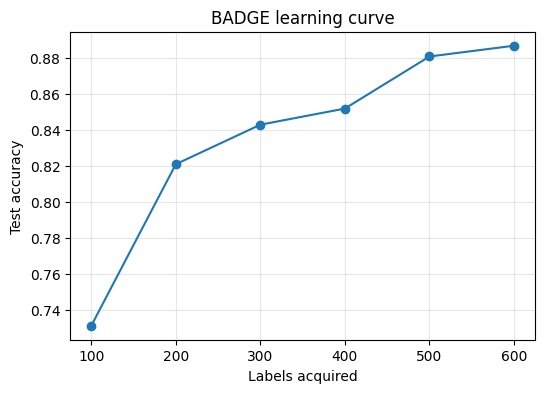

In [12]:
plt.figure(figsize=(6, 4))
plt.plot(labels_history, accuracy_history, marker="o")
plt.xlabel("Labels acquired")
plt.ylabel("Test accuracy")
plt.title("BADGE learning curve")
plt.grid(True, alpha=0.3)
plt.show()

<a id="sec-6-use-your-own-data"></a>

## 6. Use your own data

Replace the bundled loader inputs with your own supported `.pt`, `.json`, or `.csv` data. Keep the feature and label shapes expected by the package model.